In [1]:
import torch
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


In [2]:
import urllib.request
import os

url = 'https://storage.googleapis.com/3d-shapes/3dshapes.h5'
path = '3dshapes.h5'

if not os.path.exists(path):
    print('Downloading 3D Shapes (~255MB)...')
    urllib.request.urlretrieve(url, path)
    print('Done.')
else:
    print('3D Shapes already downloaded.')

Done.


In [ ]:
import h5py # library for reading HDF5 files (.h5), which is the format 3D Shapes is stored in
import numpy as np

with h5py.File('3dshapes.h5', 'r') as f:  # opens the images
    imgs = f['images'][:]        # (480000, 64, 64, 3) uint8
    labels = f['labels'][:]      # (480000, 6) float64

print('Images shape:', imgs.shape)
print('Images dtype:', imgs.dtype)
print('Labels shape:', labels.shape)
print('Latent factors: floor hue, wall hue, object hue, scale, shape, orientation')

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
indices = np.random.randint(0, len(imgs), size=10)

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(imgs[idx])
    ax.axis('off')

plt.suptitle('Random 3D Shapes samples')
plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class Shapes3DDataset(Dataset):
    def __init__(self, images):
        self.images = images
        self.transform = T.Compose([
            T.ToTensor(),  # (H, W, C) uint8 -> (C, H, W) float [0,1]
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.transform(self.images[idx])

dataset = Shapes3DDataset(imgs)
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
print(f'Dataset size: {len(dataset)}  |  Batches per epoch: {len(loader)}')

In [ ]:
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 64x64x3 -> latent
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# 4x4
            nn.ReLU(),
            nn.Flatten(),                # 256*4*4 = 4096
        )
        self.fc_mu     = nn.Linear(4096, latent_dim)
        self.fc_logvar = nn.Linear(4096, latent_dim)

        # Decoder: latent -> 64x64x3
        self.fc_decode = nn.Linear(latent_dim, 4096)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 64x64
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(self.fc_decode(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE(latent_dim=16).to(device)
print(model)

In [ ]:
import torch.optim as optim

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in loader:
        x = batch.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg = total_loss / len(dataset)
    print(f'Epoch {epoch+1}/{num_epochs}  loss: {avg:.4f}')

Epoch 1/10  loss: 131.3459
Epoch 2/10  loss: 49.9430
Epoch 3/10  loss: 42.8283
Epoch 4/10  loss: 38.6669
Epoch 5/10  loss: 35.6074
Epoch 6/10  loss: 33.5258
Epoch 7/10  loss: 32.5017
Epoch 8/10  loss: 31.5727
Epoch 9/10  loss: 30.9858
Epoch 10/10  loss: 30.4406


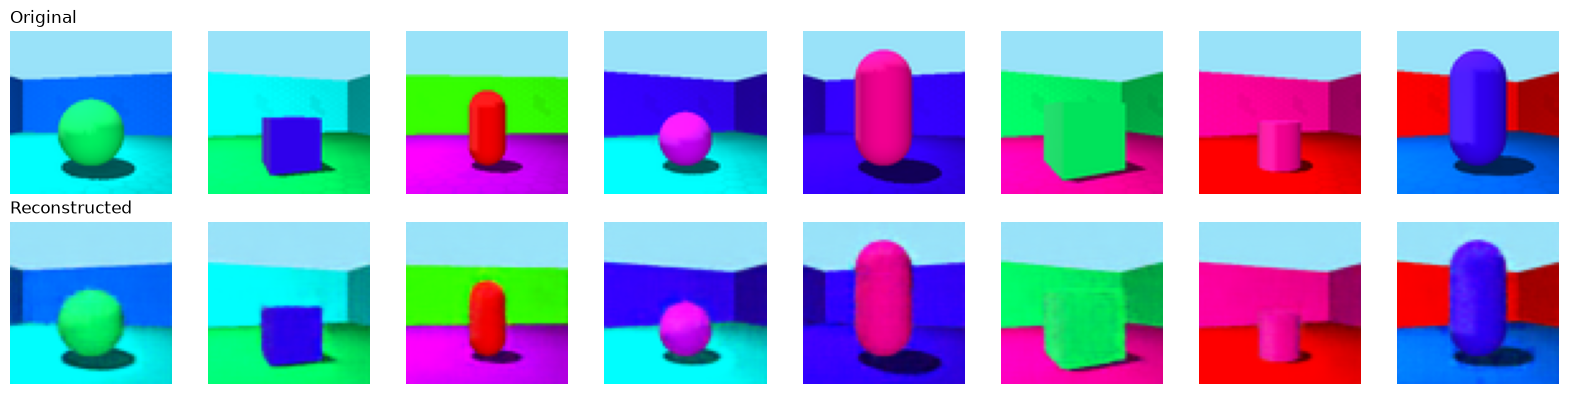

In [ ]:
model.eval()
with torch.no_grad():
    sample_batch = next(iter(loader))[:8].to(device)
    recon, _, _ = model(sample_batch)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(sample_batch[i].cpu().permute(1, 2, 0))
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].cpu().permute(1, 2, 0))
    axes[1, i].axis('off')

axes[0, 0].set_title('Original', loc='left')
axes[1, 0].set_title('Reconstructed', loc='left')
plt.tight_layout()
plt.show()

In [ ]:
torch.save({
    'model_state': model.state_dict(),
    'latent_dim': 16,
}, 'vae_trained.pt')

print('Model saved to vae_trained.pt')

Model saved to vae_trained.pt


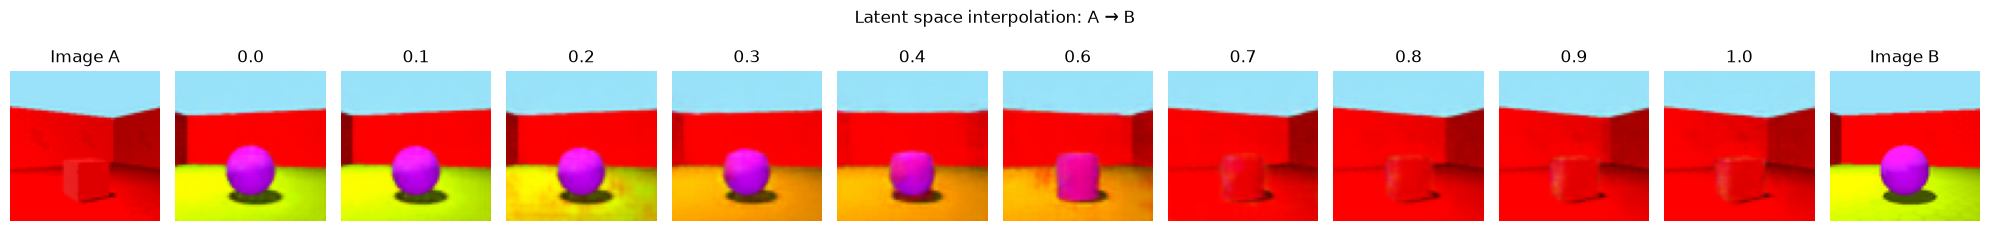

In [ ]:

# Pick two images
idx1, idx2 = 0, 100000
x1 = dataset[idx1].unsqueeze(0).to(device)  # (1, 3, 64, 64)
x2 = dataset[idx2].unsqueeze(0).to(device)

with torch.no_grad():
    mu1, _ = model.encode(x1)
    mu2, _ = model.encode(x2)

# Interpolate: z = alpha * z1 + (1 - alpha) * z2
n_steps = 10
alphas = torch.linspace(0, 1, n_steps)

interpolated = []
with torch.no_grad():
    for alpha in alphas:
        z = alpha * mu1 + (1 - alpha) * mu2
        img = model.decode(z).squeeze(0).cpu().permute(1, 2, 0)
        interpolated.append(img)

# Plot
fig, axes = plt.subplots(1, n_steps + 2, figsize=(20, 2.5))

axes[0].imshow(x1.squeeze().cpu().permute(1, 2, 0))
axes[0].set_title('Image A')
axes[0].axis('off')

for i, img in enumerate(interpolated):
    axes[i + 1].imshow(img)
    axes[i + 1].set_title(f'{alphas[i]:.1f}')
    axes[i + 1].axis('off')

axes[-1].imshow(x2.squeeze().cpu().permute(1, 2, 0))
axes[-1].set_title('Image B')
axes[-1].axis('off')

plt.suptitle('Latent space interpolation: A → B')
plt.tight_layout()
plt.show()

In [ ]:
def mutual_information_gap(model, dataset, labels, device, n_samples=10000, n_bins=20):
    """
    Compute the Mutual Information Gap (MIG) disentanglement score.

    For each ground truth factor k:
      MIG_k = (MI(z_top1, v_k) - MI(z_top2, v_k)) / H(v_k)
    where z_top1 and z_top2 are the latent dims with the highest and
    second-highest MI with factor k.

    Overall MIG = mean over all factors. Range: [0, 1], higher is better.
    """
    model.eval()

    # Encode a random subset of images
    indices = np.random.choice(len(dataset), size=n_samples, replace=False)
    mus = []
    with torch.no_grad():
        for i in range(0, n_samples, 256):
            batch_idx = indices[i:i + 256]
            batch = torch.stack([dataset[int(j)] for j in batch_idx]).to(device)
            mu, _ = model.encode(batch)
            mus.append(mu.cpu().numpy())

    mus = np.concatenate(mus, axis=0)       # (n_samples, latent_dim)
    factors = labels[indices]               # (n_samples, 6)

    n_factors = factors.shape[1]
    latent_dim = mus.shape[1]

    # Bin continuous latents into n_bins discrete bins
    mus_binned = np.zeros_like(mus, dtype=int)
    for j in range(latent_dim):
        edges = np.linspace(mus[:, j].min(), mus[:, j].max(), n_bins + 1)[1:-1]
        mus_binned[:, j] = np.digitize(mus[:, j], bins=edges)

    # Map factor values to integer indices
    factors_binned = np.zeros_like(factors, dtype=int)
    for k in range(n_factors):
        unique_vals = np.unique(factors[:, k])
        val_to_idx = {v: i for i, v in enumerate(unique_vals)}
        factors_binned[:, k] = np.array([val_to_idx[v] for v in factors[:, k]])

    def entropy(x):
        _, counts = np.unique(x, return_counts=True)
        p = counts / counts.sum()
        return -np.sum(p * np.log(p + 1e-10))

    def mutual_information(z_j, v_k):
        h_vk = entropy(v_k)
        # H(V_k | Z_j) = sum_z p(z) * H(V_k | Z_j = z)
        h_vk_given_zj = sum(
            (z_j == z).mean() * entropy(v_k[z_j == z])
            for z in np.unique(z_j)
        )
        return h_vk - h_vk_given_zj

    # MI matrix: rows = latent dims, cols = factors
    mi_matrix = np.zeros((latent_dim, n_factors))
    for j in range(latent_dim):
        for k in range(n_factors):
            mi_matrix[j, k] = mutual_information(mus_binned[:, j], factors_binned[:, k])

    factor_names = ['floor hue', 'wall hue', 'object hue', 'scale', 'shape', 'orientation']
    mig_per_factor = []
    for k in range(n_factors):
        h_vk = entropy(factors_binned[:, k])
        sorted_mi = np.sort(mi_matrix[:, k])[::-1]
        mig_per_factor.append((sorted_mi[0] - sorted_mi[1]) / (h_vk + 1e-10))

    return np.mean(mig_per_factor), mig_per_factor, factor_names, mi_matrix

In [ ]:
import os

def beta_vae_loss(recon_x, x, mu, logvar, beta):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl

betas = [1, 2, 4, 6, 8, 10]
num_epochs = 10
save_dir = 'beta_sweep'
os.makedirs(save_dir, exist_ok=True)

sweep_results = []  # list of dicts: beta, final_loss, mig_score, checkpoint_path

for beta in betas:
    print(f'\n=== Beta = {beta} ===')

    # Fresh model for each beta
    beta_model = VAE(latent_dim=16).to(device)
    optimizer = optim.Adam(beta_model.parameters(), lr=1e-3)

    epoch_losses = []
    for epoch in range(num_epochs):
        beta_model.train()
        total_loss = 0
        for batch in loader:
            x = batch.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = beta_model(x)
            loss = beta_vae_loss(recon, x, mu, logvar, beta)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg = total_loss / len(dataset)
        epoch_losses.append(avg)
        print(f'  Epoch {epoch+1}/{num_epochs}  loss: {avg:.4f}')

    # Save checkpoint
    ckpt_path = os.path.join(save_dir, f'beta_{beta}.pt')
    torch.save({
        'beta': beta,
        'model_state': beta_model.state_dict(),
        'epoch_losses': epoch_losses,
    }, ckpt_path)

    # Compute MIG
    mig_score, mig_per_factor, factor_names, _ = mutual_information_gap(
        beta_model, dataset, labels, device, n_samples=10000, n_bins=20
    )

    sweep_results.append({
        'beta': beta,
        'final_loss': epoch_losses[-1],
        'mig_score': mig_score,
        'mig_per_factor': mig_per_factor,
        'checkpoint': ckpt_path,
    })
    print(f'  MIG: {mig_score:.4f}')

print('\n=== Sweep complete ===')
print(f'{"Beta":>6}  {"Final Loss":>12}  {"MIG":>8}')
for r in sweep_results:
    print(f'{r["beta"]:>6}  {r["final_loss"]:>12.4f}  {r["mig_score"]:>8.4f}')

best = max(sweep_results, key=lambda r: r['mig_score'])
print(f'\nBest beta = {best["beta"]}  (MIG = {best["mig_score"]:.4f})')

In [ ]:
# Load the best model from the sweep
best = max(sweep_results, key=lambda r: r['mig_score'])
ckpt = torch.load(best['checkpoint'], map_location=device)

best_model = VAE(latent_dim=16).to(device)
best_model.load_state_dict(ckpt['model_state'])
best_model.eval()

print(f'Loaded best model: beta = {best["beta"]}  MIG = {best["mig_score"]:.4f}')

# Plot MIG vs beta
betas_plot = [r['beta'] for r in sweep_results]
migs_plot  = [r['mig_score'] for r in sweep_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(betas_plot, migs_plot, marker='o')
axes[0].axvline(best['beta'], color='red', linestyle='--', label=f'best β={best["beta"]}')
axes[0].set_xlabel('Beta')
axes[0].set_ylabel('MIG')
axes[0].set_title('MIG vs Beta')
axes[0].legend()

axes[1].plot(betas_plot, [r['final_loss'] for r in sweep_results], marker='o', color='orange')
axes[1].set_xlabel('Beta')
axes[1].set_ylabel('Final loss')
axes[1].set_title('Loss vs Beta')

plt.tight_layout()
plt.show()